Pixel evitati: 98406 su 284592 totali
Percentuale di ottimizzazione: 34.58%
--- 0.21154236793518066 seconds ---


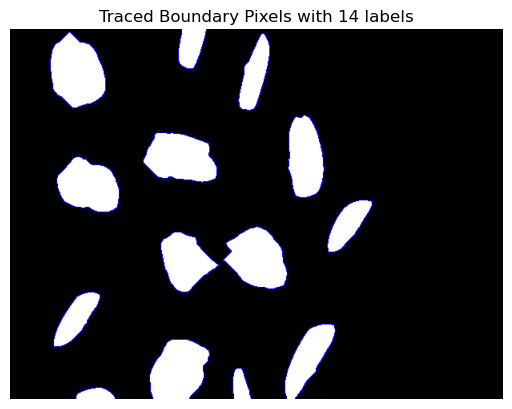

Number of boundaries found: 14


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque

def trace_boundary(binary_image):
    """Finds and traces all boundary pixels in a binary image using BFS with 8-connectivity."""
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    visited = np.zeros((h, w), dtype=bool)  # Track visited pixels
    labels = np.zeros((h, w), dtype=int)  # Store labels of each boundary pixel
    current_label = 1  # Start labeling from 1

    # ANALISI PRELIMINARE: Trova il bounding box dell'area di interesse
    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    total_pixels = h * w
    analyzed_pixels = (bottom - top) * (right - left)
    skipped_pixels = total_pixels - analyzed_pixels
    
    print(f"Pixel evitati: {skipped_pixels} su {total_pixels} totali")
    print(f"Percentuale di ottimizzazione: {skipped_pixels / total_pixels * 100:.2f}%")
    
    # 8-connectivity (Up, Down, Left, Right, and Diagonals)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1),   # Up, Down, Left, Right
                  (-1, -1), (-1, 1), (1, -1), (1, 1)] # Diagonals

    def bfs(start_i, start_j):
        """Perform BFS to trace the boundary from a starting pixel and label the boundary."""
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:  # Skip if already processed
                continue
            
            visited[i, j] = True  # Mark as visited
            boundary_mask[i, j] = 255  # Mark as boundary
            labels[i, j] = current_label  # Assign the current label to this pixel

            # Explore neighbors to find background-touching pixels
            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:  # If it's a foreground pixel
                        # Now check if any neighbor of this pixel touches the background (0)
                        boundary_found = False
                        for dx2, dy2 in directions:  # Check all 8 directions of the neighbor
                            ni2, nj2 = ni + dx2, nj + dy2
                            if 0 <= ni2 < h and 0 <= nj2 < w and binary_image[ni2, nj2] == 0:
                                boundary_found = True
                                break  # Stop as soon as we find one background pixel
                        if boundary_found:
                            queue.append((ni, nj))  # Enqueue the pixel if it touches background

    # Scan the entire image to find all boundary objects
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:  # Found a new boundary
                # Check if this pixel touches the background (0)
                for dx, dy in directions:
                    ni, nj = i + dx, j + dy
                    if 0 <= ni < h and 0 <= nj < w and binary_image[ni, nj] == 0:
                        bfs(i, j)  # Start BFS from this boundary
                        current_label += 1  # Increment label for the next boundary
                        break  # Stop checking neighbors once we start BFS

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1  # Return final boundary mask, labels, and number of labels

# Load the image and convert it to grayscale
beans_img = cv2.imread('000005.bmp')
img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)

# Crop the borders
height, width = img_gray.shape
border_x = int(height * 0.02)  
border_y = int(width * 0.02)   
img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]

# Segmentation
threshold = 75
_, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)

# Morphological Operations
kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=15)

kernel_open = np.ones((3,3), np.uint8)
img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)

# Trace the boundary
boundary_mask, labels, num_labels = trace_boundary(img_opened)

# Visualize boundary pixels with color
colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)  # Convert to 3-channel image (BGR)
colored_img[boundary_mask == 255] = [0, 0, 255]  # Color the boundary pixels red

# Display the results
plt.imshow(colored_img)
plt.axis('off')
plt.title(f"Traced Boundary Pixels with {num_labels} labels")
plt.show()

# Output the number of found labels (boundaries)
print(f"Number of boundaries found: {num_labels}")


